# HW05 — Регрессия функции двух переменных (PyTorch)

Аппроксимация функции

$$f(x, y) = \sin(x + 2y) \cdot \exp\left(-(2x + y)^2\right)$$

на диапазоне $x, y \in [-10; 10]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

In [2]:
def target_function(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.sin(x + 2 * y) * torch.exp(-(2 * x + y) ** 2)


torch.manual_seed(42)
N = 20_000

x = torch.empty(N).uniform_(-10, 10)
y = torch.empty(N).uniform_(-10, 10)
z = target_function(x, y)

features = torch.stack([x, y], dim=1)
targets = z.unsqueeze(1)

dataset = TensorDataset(features, targets)

n_train = int(0.7 * N)
n_test = int(0.15 * N)
n_val = N - n_train - n_test

train_dataset, test_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_test, n_val],
    generator=torch.Generator().manual_seed(42),
)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}, Val: {len(val_dataset)}")

Train: 14000, Test: 3000, Val: 3000


In [3]:
class RegressionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


BATCH_SIZE = 256
EPOCHS = 200
LEARNING_RATE = 1e-3

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = RegressionNet()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            preds = model(batch_x)
            val_loss += criterion(preds, batch_y).item() * batch_x.size(0)
    val_loss /= len(val_dataset)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train MSE: {train_loss:.6e} | val MSE: {val_loss:.6e}")

Epoch   1 | train MSE: 1.896568e-02 | val MSE: 1.539739e-02
Epoch  20 | train MSE: 9.157173e-03 | val MSE: 8.911718e-03
Epoch  40 | train MSE: 3.761627e-03 | val MSE: 5.004895e-03
Epoch  60 | train MSE: 1.014757e-03 | val MSE: 1.020591e-03
Epoch  80 | train MSE: 6.055542e-04 | val MSE: 7.707177e-04
Epoch 100 | train MSE: 5.111921e-04 | val MSE: 6.006361e-04
Epoch 120 | train MSE: 2.961255e-04 | val MSE: 4.996279e-04
Epoch 140 | train MSE: 2.974265e-04 | val MSE: 2.299717e-04
Epoch 160 | train MSE: 1.591703e-04 | val MSE: 2.929364e-04
Epoch 180 | train MSE: 3.631207e-04 | val MSE: 3.307854e-04
Epoch 200 | train MSE: 1.368510e-04 | val MSE: 2.015055e-04


In [4]:
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

model.eval()
test_mse = 0.0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        preds = model(batch_x)
        test_mse += criterion(preds, batch_y).item() * batch_x.size(0)
test_mse /= len(test_dataset)

print(f"Test MSE: {test_mse:.6e}")

Test MSE: 2.048708e-04


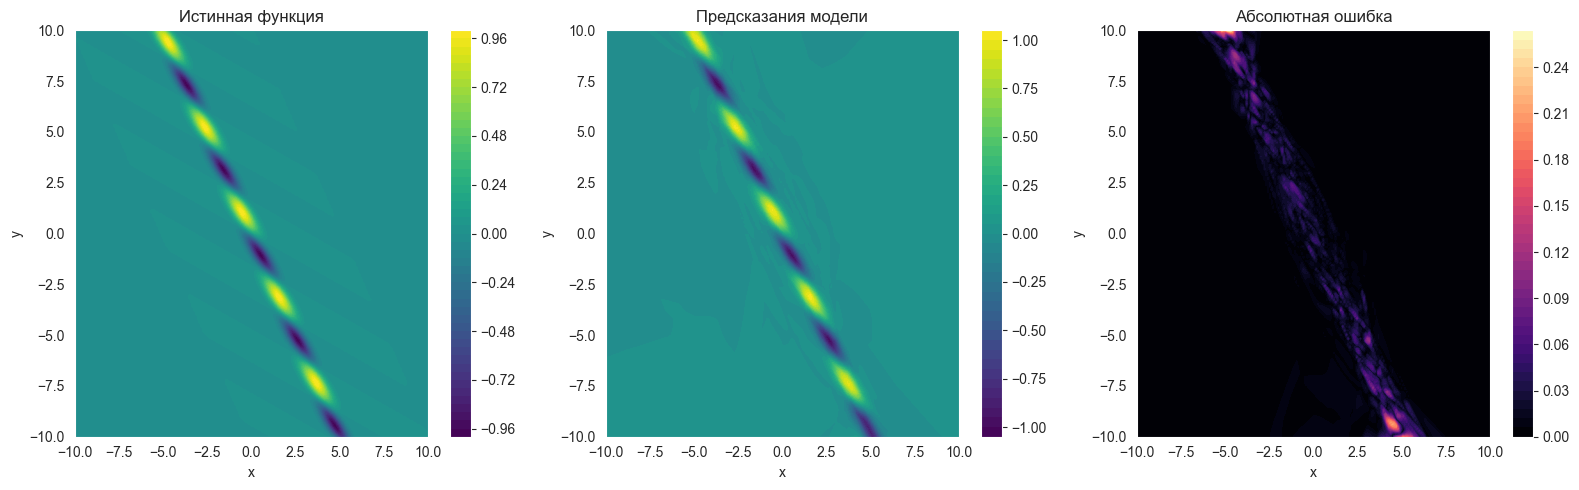

In [5]:
grid_size = 200
xs = torch.linspace(-10, 10, grid_size)
ys = torch.linspace(-10, 10, grid_size)
X, Y = torch.meshgrid(xs, ys, indexing="xy")

grid_points = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

with torch.no_grad():
    Z_true = target_function(X, Y).numpy()
    Z_pred = model(grid_points).reshape(grid_size, grid_size).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].contourf(X.numpy(), Y.numpy(), Z_true, levels=50, cmap="viridis")
axes[0].set_title("Истинная функция")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X.numpy(), Y.numpy(), Z_pred, levels=50, cmap="viridis")
axes[1].set_title("Предсказания модели")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X.numpy(), Y.numpy(), np.abs(Z_true - Z_pred), levels=50, cmap="magma")
axes[2].set_title("Абсолютная ошибка")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()